In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import corner

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Veri Seti

Verilen gerçek parlaklık, gözlem hatası ve gözlem sayısı kullanılarak sentetik veri oluşturulmuştur.

In [2]:
# temel simulasyon degerleri
TRUE_MU = 150.0
TRUE_SIGMA = 10.0
N_OBS = 50
RANDOM_SEED = 42


def make_synthetic_data(n_obs, true_mu=TRUE_MU, true_sigma=TRUE_SIGMA, seed=RANDOM_SEED):
    """np.random.seed + randn mantığıyla sentetik gözlem üretir."""
    rng = np.random.RandomState(seed)
    return true_mu + true_sigma * rng.randn(n_obs)


data = make_synthetic_data(N_OBS)

print(f"Gözlem sayısı: {len(data)}")
print(f"Örnek ortalaması: {np.mean(data):.3f}")
print(f"Örnek standart sapması: {np.std(data, ddof=1):.3f}")
print(f"İlk 10 gözlem: {np.round(data[:10], 3)}")

Gözlem sayısı: 50
Örnek ortalaması: 147.745
Örnek standart sapması: 9.337
İlk 10 gözlem: [154.967 148.617 156.477 165.23  147.658 147.659 165.792 157.674 145.305
 155.426]


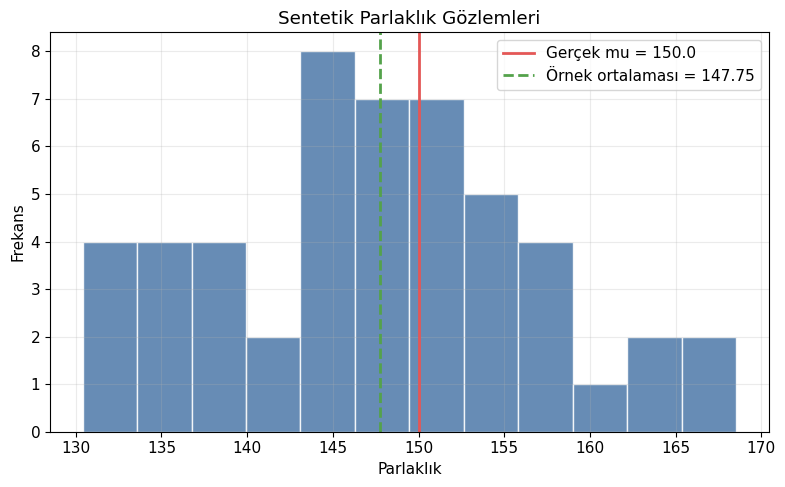

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data, bins=12, color="#4C78A8", edgecolor="white", alpha=0.85)
ax.axvline(TRUE_MU, color="#E45756", linewidth=2, label=f"Gerçek mu = {TRUE_MU}")
ax.axvline(np.mean(data), color="#54A24B", linewidth=2, linestyle="--", label=f"Örnek ortalaması = {np.mean(data):.2f}")
ax.set_title("Sentetik Parlaklık Gözlemleri")
ax.set_xlabel("Parlaklık")
ax.set_ylabel("Frekans")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "01_sentetik_veri_histogram.png", dpi=160)
plt.show()

# Bayesyen Model

Normal dağılım varsayımıyla log-likelihood, geniş prior ve log-posterior fonksiyonları tanımlanmıştır.

In [4]:
# posterior hesabi icin gerekli fonksiyonlar
def log_likelihood(theta, observed_data):
    mu, sigma = theta
    if sigma <= 0:
        return -np.inf
    residual_term = ((observed_data - mu) / sigma) ** 2
    normalization_term = np.log(2 * np.pi * sigma**2)
    return -0.5 * np.sum(residual_term + normalization_term)


def make_log_prior(mu_bounds=(0, 300), sigma_bounds=(0, 50)):
    """Verilen sınırlarla uniform log-prior fonksiyonu üretir."""
    mu_min, mu_max = mu_bounds
    sigma_min, sigma_max = sigma_bounds

    def log_prior(theta):
        mu, sigma = theta
        if mu_min < mu < mu_max and sigma_min < sigma < sigma_max:
            return 0.0
        return -np.inf

    return log_prior


wide_prior = make_log_prior(mu_bounds=(0, 300), sigma_bounds=(0, 50))


def log_probability(theta, observed_data, log_prior_fn=wide_prior):
    lp = log_prior_fn(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, observed_data)

# MCMC Fonksiyonları

MCMC çalıştırma ve posterior örneklerini özetleme işlemleri tekrar kullanılabilir fonksiyonlar haline getirilmiştir.

In [5]:
# mcmc ornekleme islemi
def run_mcmc(
    observed_data,
    log_prior_fn=wide_prior,
    initial=(140, 5),
    n_walkers=32,
    n_steps=2000,
    burn_in=500,
    thin=15,
    seed=123,
    progress=True,
):
    ndim = 2
    rng = np.random.RandomState(seed)
    pos = np.array(initial, dtype=float) + 1e-4 * rng.randn(n_walkers, ndim)

    sampler = emcee.EnsembleSampler(
        n_walkers,
        ndim,
        log_probability,
        args=(observed_data, log_prior_fn),
    )
    sampler.run_mcmc(pos, n_steps, progress=progress)

    flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)

    try:
        autocorr_time = sampler.get_autocorr_time(tol=0)
    except Exception:
        autocorr_time = None

    return {
        "sampler": sampler,
        "flat_samples": flat_samples,
        "acceptance_fraction": float(np.mean(sampler.acceptance_fraction)),
        "autocorr_time": autocorr_time,
        "burn_in": burn_in,
        "thin": thin,
        "n_steps": n_steps,
        "n_walkers": n_walkers,
    }


# posterior orneklerinden tablo degerleri cikarilir
def summarize_samples(samples, true_values=(TRUE_MU, TRUE_SIGMA)):
    labels = ["mu (Parlaklık)", "sigma (Hata Payı)"]
    percentiles = np.percentile(samples, [2.5, 16, 50, 84, 97.5], axis=0)
    p025, p16, p50, p84, p975 = percentiles

    rows = []
    for i, label in enumerate(labels):
        absolute_error = abs(p50[i] - true_values[i])
        relative_error = 100 * absolute_error / true_values[i]
        rows.append(
            {
                "Değişken": label,
                "Gerçek Değer": true_values[i],
                "Tahmin Edilen Median": p50[i],
                "Alt Sınır (%16)": p16[i],
                "Üst Sınır (%84)": p84[i],
                "Alt Sınır (%2.5)": p025[i],
                "Üst Sınır (%97.5)": p975[i],
                "68% Genişlik": p84[i] - p16[i],
                "95% Genişlik": p975[i] - p025[i],
                "Mutlak Hata": absolute_error,
                "Hata (%)": relative_error,
            }
        )

    return pd.DataFrame(rows)


def display_rounded(df, digits=3):
    return display(df.round(digits))

# Ana MCMC Deneyi

n=50 gözlem için geniş prior kullanılarak MCMC örneklemesi çalıştırılmıştır.

In [6]:
base_result = run_mcmc(
    data,
    log_prior_fn=wide_prior,
    initial=(140, 5),
    n_walkers=32,
    n_steps=2000,
    burn_in=500,
    thin=15,
    seed=123,
    progress=True,
)

print(f"Ortalama kabul oranı: {base_result['acceptance_fraction']:.3f}")
if base_result["autocorr_time"] is not None:
    print("Yaklaşık autocorrelation time:", np.round(base_result["autocorr_time"], 2))
print("Posterior örnek sayısı:", len(base_result["flat_samples"]))

100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 954.06it/s]

Ortalama kabul oranı: 0.712
Yaklaşık autocorrelation time: [45.34 35.88]
Posterior örnek sayısı: 3200


In [7]:
summary_base = summarize_samples(base_result["flat_samples"])
display_rounded(summary_base)

,Değişken,Gerçek Değer,Tahmin Edilen Median,Alt Sınır (%16),Üst Sınır (%84),Alt Sınır (%2.5),Üst Sınır (%97.5),68% Genişlik,95% Genişlik,Mutlak Hata,Hata (%)
0,mu (Parlaklık),150.0,147.728,146.385,149.053,145.054,150.404,2.668,5.350,2.272,1.515
1,sigma (Hata Payı),10.0,9.503,8.614,10.618,7.958,11.791,2.004,3.834,0.497,4.967


Elde edilen median, alt sınır, üst sınır ve mutlak hata değerleri rapordaki parametre karşılaştırma tablosu için kullanılabilir.

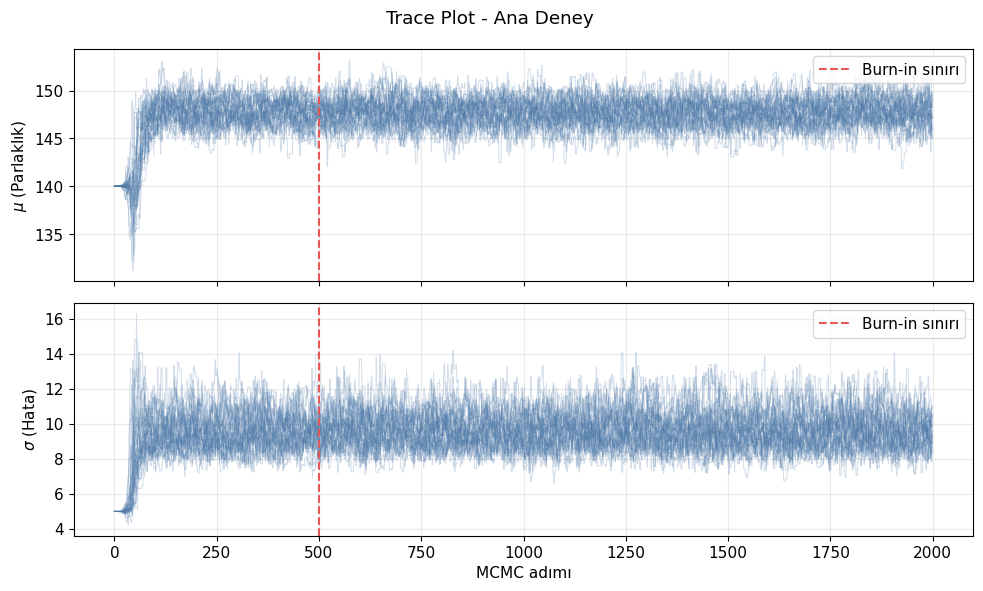

In [8]:
chain = base_result["sampler"].get_chain()
parameter_names = [r"$\mu$ (Parlaklık)", r"$\sigma$ (Hata)"]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain[:, :, i], color="#4C78A8", alpha=0.25, linewidth=0.7)
    ax.set_ylabel(parameter_names[i])
    ax.axvline(base_result["burn_in"], color="#E45756", linestyle="--", label="Burn-in sınırı")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("MCMC adımı")
fig.suptitle("Trace Plot - Ana Deney")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_trace_plot_ana_deney.png", dpi=160)
plt.show()

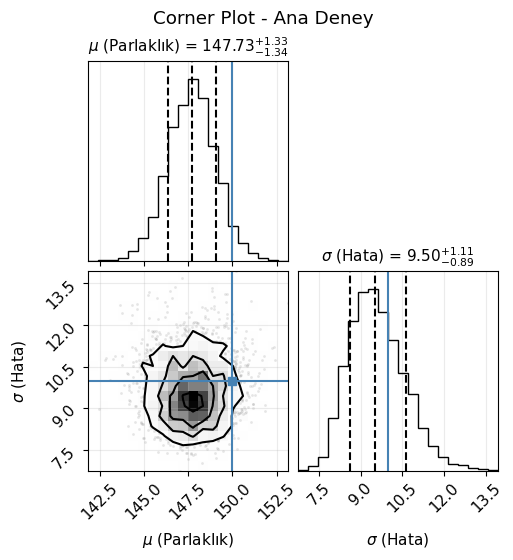

In [9]:
fig = corner.corner(
    base_result["flat_samples"],
    labels=parameter_names,
    truths=[TRUE_MU, TRUE_SIGMA],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 11},
)
fig.suptitle("Corner Plot - Ana Deney", y=1.02)
fig.savefig(FIG_DIR / "03_corner_plot_ana_deney.png", dpi=160, bbox_inches="tight")
plt.show()

# Prior Etkisi

Parlaklık için dar ve hatalı bir prior seçildiğinde posterior tahmininin nasıl değiştiği incelenmiştir.

In [10]:
# dar prior etkisi icin yeni sinirlar kullanilir
narrow_prior = make_log_prior(mu_bounds=(100, 110), sigma_bounds=(0, 50))

narrow_prior_result = run_mcmc(
    data,
    log_prior_fn=narrow_prior,
    initial=(105, 10),
    n_walkers=32,
    n_steps=2000,
    burn_in=500,
    thin=15,
    seed=456,
    progress=True,
)

summary_narrow_prior = summarize_samples(narrow_prior_result["flat_samples"])
display_rounded(summary_narrow_prior)

100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 932.48it/s]


,Değişken,Gerçek Değer,Tahmin Edilen Median,Alt Sınır (%16),Üst Sınır (%84),Alt Sınır (%2.5),Üst Sınır (%97.5),68% Genişlik,95% Genişlik,Mutlak Hata,Hata (%)
0,mu (Parlaklık),150.0,109.440,108.530,109.856,107.095,109.976,1.326,2.882,40.560,27.040
1,sigma (Hata Payı),10.0,40.286,36.493,44.416,33.155,48.221,7.923,15.066,30.286,302.865


In [11]:
prior_comparison = pd.DataFrame(
    {
        "Parametre": ["mu", "sigma"],
        "Geniş Prior Median": summary_base["Tahmin Edilen Median"].values,
        "Dar Prior Median": summary_narrow_prior["Tahmin Edilen Median"].values,
        "Gerçek Değer": [TRUE_MU, TRUE_SIGMA],
        "Geniş Prior Mutlak Hata": summary_base["Mutlak Hata"].values,
        "Dar Prior Mutlak Hata": summary_narrow_prior["Mutlak Hata"].values,
    }
)
display_rounded(prior_comparison)

,Parametre,Geniş Prior Median,Dar Prior Median,Gerçek Değer,Geniş Prior Mutlak Hata,Dar Prior Mutlak Hata
0,mu,147.728,109.440,150.0,2.272,40.560
1,sigma,9.503,40.286,10.0,0.497,30.286


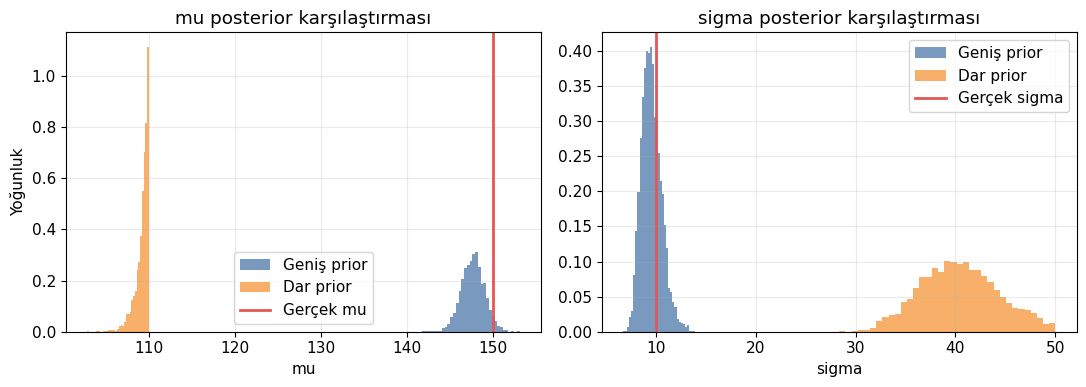

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(base_result["flat_samples"][:, 0], bins=35, alpha=0.75, label="Geniş prior", color="#4C78A8", density=True)
axes[0].hist(narrow_prior_result["flat_samples"][:, 0], bins=35, alpha=0.65, label="Dar prior", color="#F58518", density=True)
axes[0].axvline(TRUE_MU, color="#E45756", linewidth=2, label="Gerçek mu")
axes[0].set_title("mu posterior karşılaştırması")
axes[0].set_xlabel("mu")
axes[0].set_ylabel("Yoğunluk")
axes[0].legend()

axes[1].hist(base_result["flat_samples"][:, 1], bins=35, alpha=0.75, label="Geniş prior", color="#4C78A8", density=True)
axes[1].hist(narrow_prior_result["flat_samples"][:, 1], bins=35, alpha=0.65, label="Dar prior", color="#F58518", density=True)
axes[1].axvline(TRUE_SIGMA, color="#E45756", linewidth=2, label="Gerçek sigma")
axes[1].set_title("sigma posterior karşılaştırması")
axes[1].set_xlabel("sigma")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "04_prior_etkisi_karsilastirma.png", dpi=160)
plt.show()

# Veri Miktarı Etkisi

Gözlem sayısı 50 yerine 5 yapıldığında posterior belirsizliğinin nasıl değiştiği incelenmiştir.

In [13]:
# az gozlem sayisi ile ayni analiz tekrarlanir
small_data = make_synthetic_data(5)

print(f"n_obs=5 veri: {np.round(small_data, 3)}")
print(f"n_obs=5 örnek ortalaması: {np.mean(small_data):.3f}")
print(f"n_obs=5 örnek standart sapması: {np.std(small_data, ddof=1):.3f}")

small_data_result = run_mcmc(
    small_data,
    log_prior_fn=wide_prior,
    initial=(140, 5),
    n_walkers=32,
    n_steps=2000,
    burn_in=500,
    thin=15,
    seed=789,
    progress=True,
)

summary_small_data = summarize_samples(small_data_result["flat_samples"])
display_rounded(summary_small_data)

n_obs=5 veri: [154.967 148.617 156.477 165.23  147.658]
n_obs=5 örnek ortalaması: 154.590
n_obs=5 örnek standart sapması: 7.082


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 904.16it/s]


,Değişken,Gerçek Değer,Tahmin Edilen Median,Alt Sınır (%16),Üst Sınır (%84),Alt Sınır (%2.5),Üst Sınır (%97.5),68% Genişlik,95% Genişlik,Mutlak Hata,Hata (%)
0,mu (Parlaklık),150.0,154.683,150.600,158.995,144.580,165.779,8.395,21.199,4.683,3.122
1,sigma (Hata Payı),10.0,8.827,6.134,14.242,4.613,27.076,8.109,22.463,1.173,11.732


In [14]:
data_amount_comparison = pd.DataFrame(
    {
        "Parametre": ["mu", "sigma"],
        "n=50 Median": summary_base["Tahmin Edilen Median"].values,
        "n=50 68% Genişlik": summary_base["68% Genişlik"].values,
        "n=5 Median": summary_small_data["Tahmin Edilen Median"].values,
        "n=5 68% Genişlik": summary_small_data["68% Genişlik"].values,
        "Genişlik Artış Oranı": summary_small_data["68% Genişlik"].values / summary_base["68% Genişlik"].values,
    }
)
display_rounded(data_amount_comparison)

,Parametre,n=50 Median,n=50 68% Genişlik,n=5 Median,n=5 68% Genişlik,Genişlik Artış Oranı
0,mu,147.728,2.668,154.683,8.395,3.146
1,sigma,9.503,2.004,8.827,8.109,4.047


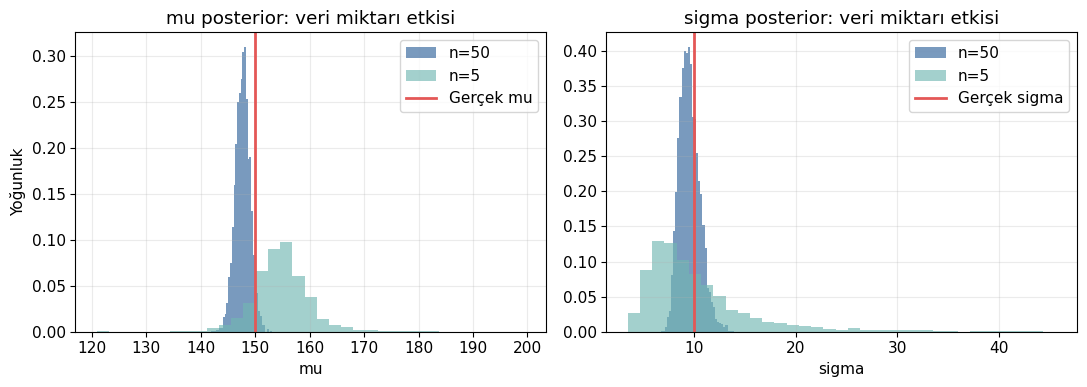

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(base_result["flat_samples"][:, 0], bins=35, alpha=0.75, label="n=50", color="#4C78A8", density=True)
axes[0].hist(small_data_result["flat_samples"][:, 0], bins=35, alpha=0.65, label="n=5", color="#72B7B2", density=True)
axes[0].axvline(TRUE_MU, color="#E45756", linewidth=2, label="Gerçek mu")
axes[0].set_title("mu posterior: veri miktarı etkisi")
axes[0].set_xlabel("mu")
axes[0].set_ylabel("Yoğunluk")
axes[0].legend()

axes[1].hist(base_result["flat_samples"][:, 1], bins=35, alpha=0.75, label="n=50", color="#4C78A8", density=True)
axes[1].hist(small_data_result["flat_samples"][:, 1], bins=35, alpha=0.65, label="n=5", color="#72B7B2", density=True)
axes[1].axvline(TRUE_SIGMA, color="#E45756", linewidth=2, label="Gerçek sigma")
axes[1].set_title("sigma posterior: veri miktarı etkisi")
axes[1].set_xlabel("sigma")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "05_veri_miktari_karsilastirma.png", dpi=160)
plt.show()

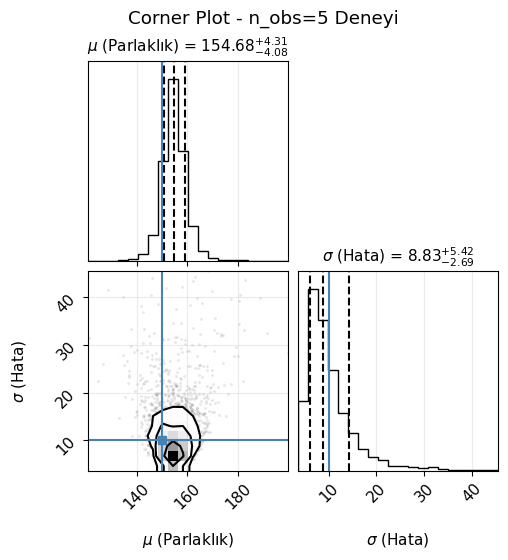

In [16]:
fig = corner.corner(
    small_data_result["flat_samples"],
    labels=parameter_names,
    truths=[TRUE_MU, TRUE_SIGMA],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 11},
)
fig.suptitle("Corner Plot - n_obs=5 Deneyi", y=1.02)
fig.savefig(FIG_DIR / "06_corner_plot_n_obs_5.png", dpi=160, bbox_inches="tight")
plt.show()

# Rapor Çıktıları

Ana tablo, prior karşılaştırması, veri miktarı karşılaştırması ve corner plot çıktıları rapor yazımında kullanılmak üzere hazırlanmıştır.

In [17]:
print("Ana deney rapor değerleri")
for _, row in summary_base.iterrows():
    print(
        f"{row['Değişken']}: median={row['Tahmin Edilen Median']:.3f}, "
        f"%16={row['Alt Sınır (%16)']:.3f}, "
        f"%84={row['Üst Sınır (%84)']:.3f}, "
        f"mutlak hata={row['Mutlak Hata']:.3f}"
    )

Ana deney rapor değerleri
mu (Parlaklık): median=147.728, %16=146.385, %84=149.053, mutlak hata=2.272
sigma (Hata Payı): median=9.503, %16=8.614, %84=10.618, mutlak hata=0.497
